# Comment-2 robustness and unification package

This notebook reproduces the second referee-comment battery (wp15 series) from aggregate artifacts:
a single canonical pipeline for every headline number (per-clock levels included), a full-design
bootstrap that re-estimates matching in every replication, rescue-purpose heterogeneity,
minority-purity exclusions, a payment-date event anchor, an entity-restructuring screen over the
outcome window (including an adverse over-conditioning diagnostic, reported deliberately), and an
entropy-balancing upgrade of the same-state comparison. Every number printed in the revision
suggestions is asserted here at its displayed rounding.


## 0. Load artifacts


In [ ]:
import json, os
import pandas as pd
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 90)
ART = "../artifacts"
def A(name):
    with open(os.path.join(ART, name + ".json"), encoding="utf-8") as f: return json.load(f)
def show(df, t): print(t); print("-" * len(t)); print(df.to_string(index=False)); print()
def f4(x): return f"{x:+.4f}"
def ci4(c): return f"[{c[0]:+.4f}, {c[1]:+.4f}]"
def okp(a, b, nd=4): assert round(a, nd) == round(b, nd), (a, b)
print("ready")


ready


## 1. Unified canonical set (one pipeline, one bootstrap)


In [ ]:
W = A("wp15_comment2_battery")["runs"]; C = W["A_canonical"]
rows = []
for s, lab in (("mean","Mean"),("median","Median"),("p10","Tenth percentile"),("p25","Twenty-fifth percentile"),
               ("sev25","Severe excess at -0.25"),("sev35","Severe excess at -0.35"),("sev50","Severe excess at -0.50")):
    rows.append({"Statistic": lab,
                 "Full (210 vs 561)": f"{f4(C['full_pooled'][s]['obs'])} {ci4(C['full_pooled'][s]['ci'])}",
                 "Common 116-firm": f"{f4(C['common_pooled'][s]['obs'])} {ci4(C['common_pooled'][s]['ci'])}"})
show(pd.DataFrame(rows), "Unified canonical set: actual event vs pooled pseudo-events (one pipeline, one bootstrap)")
okp(C["full_pooled"]["p10"]["obs"], -0.2527); okp(C["full_pooled"]["sev35"]["obs"], 0.1025)
okp(C["full_pooled"]["sev35"]["ci"][0], 0.0477); okp(C["full_pooled"]["sev35"]["ci"][1], 0.1576)
okp(C["common_pooled"]["p10"]["obs"], -0.2193); okp(C["common_pooled"]["sev35"]["obs"], 0.1056)
print(f"n common firms = {C['n_common_firms']}")
import numpy as np
print(f"economic translation: -0.35 lp = {np.expm1(-0.35):.1%}; p10 {C['full_pooled']['p10']['obs']} lp = {np.expm1(C['full_pooled']['p10']['obs']):.1%}")


Unified canonical set: actual event vs pooled pseudo-events (one pipeline, one bootstrap)
-----------------------------------------------------------------------------------------
              Statistic          Full (210 vs 561)            Common 116-firm
                   Mean -0.0481 [-0.1015, +0.0034] -0.0616 [-0.1254, -0.0004]
                 Median -0.0036 [-0.0368, +0.0246] -0.0207 [-0.0571, +0.0170]
       Tenth percentile -0.2527 [-0.3647, -0.0923] -0.2193 [-0.4008, -0.0696]
Twenty-fifth percentile -0.0641 [-0.1558, -0.0008] -0.0816 [-0.2055, -0.0040]
 Severe excess at -0.25 +0.0871 [+0.0235, +0.1503] +0.1056 [+0.0259, +0.1897]
 Severe excess at -0.35 +0.1025 [+0.0477, +0.1576] +0.1056 [+0.0366, +0.1789]
 Severe excess at -0.50 +0.0846 [+0.0405, +0.1309] +0.0797 [+0.0259, +0.1422]

n common firms = 116
economic translation: -0.35 lp = -29.5%; p10 -0.2527 lp = -22.3%


## 2. Per-clock levels and contrasts - unified Figure 1


Per-clock levels (same pipeline) - unified Figure 1 input
---------------------------------------------------------
       Clock   n           Mean matched gap              Pr(D<=-0.35)
         t36 125 -0.0058 [-0.0461, +0.0322] 0.0480 [+0.0160, +0.0880]
         t30 131 -0.0115 [-0.0435, +0.0220] 0.0534 [+0.0153, +0.0916]
         t24 142 -0.0520 [-0.0927, -0.0169] 0.0563 [+0.0211, +0.0986]
         t18 163 -0.0576 [-0.1001, -0.0186] 0.0920 [+0.0491, +0.1351]
Actual event 210 -0.0820 [-0.1289, -0.0363] 0.1667 [+0.1190, +0.2144]

Event-minus-benchmark contrasts by clock
----------------------------------------
  Benchmark     Severe excess at -0.35               p10 contrast
     vs t18 +0.0746 [+0.0097, +0.1362] -0.2035 [-0.3290, -0.0031]
     vs t24 +0.1103 [+0.0447, +0.1719] -0.2647 [-0.3937, -0.0915]
     vs t30 +0.1132 [+0.0453, +0.1784] -0.2969 [-0.4203, -0.1268]
     vs t36 +0.1187 [+0.0556, +0.1818] -0.3060 [-0.4204, -0.0998]
full_pooled +0.1025 [+0.0477, +0.1576] -0.2527 [-0.

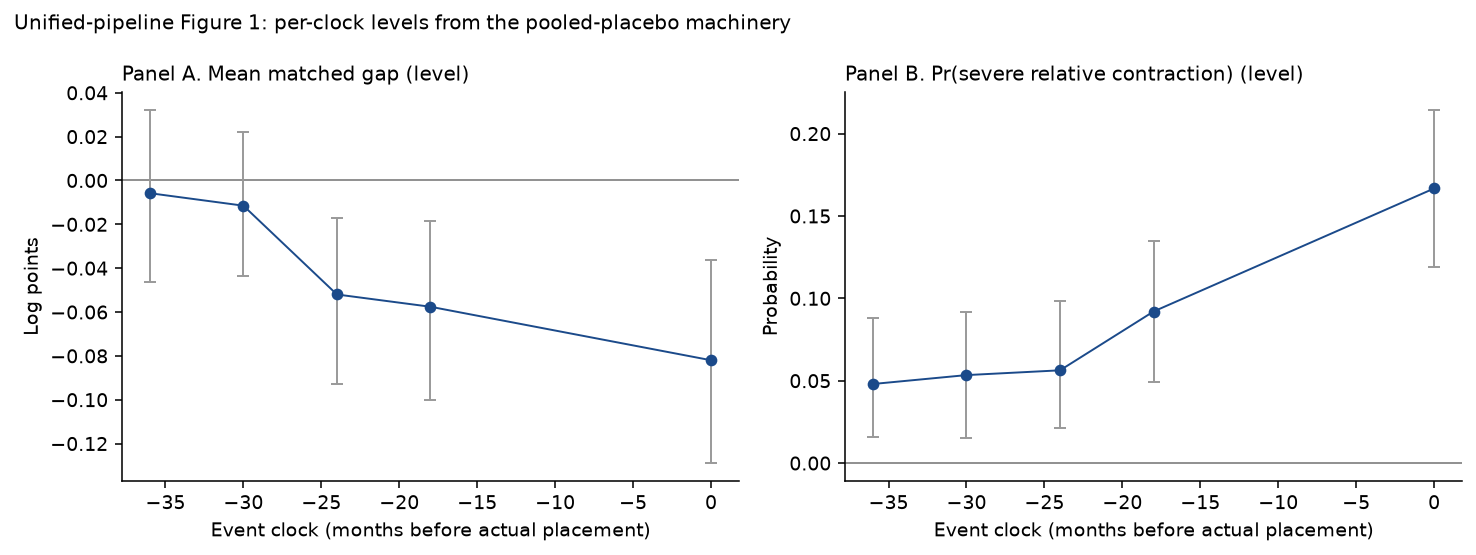

In [ ]:
E = W["E_clock_levels"]
rows = [{"Clock": k if k != "actual" else "Actual event", "n": E[k]["n"],
         "Mean matched gap": f"{f4(E[k]['mean']['obs'])} {ci4(E[k]['mean']['ci'])}",
         "Pr(D<=-0.35)": f"{E[k]['sev35']['obs']:.4f} {ci4(E[k]['sev35']['ci'])}"}
        for k in ("t36","t30","t24","t18","actual")]
show(pd.DataFrame(rows), "Per-clock levels (same pipeline) - unified Figure 1 input")
okp(E["t36"]["mean"]["obs"], -0.0058); okp(E["t24"]["mean"]["obs"], -0.0520)
okp(E["actual"]["mean"]["obs"], -0.0820); okp(E["actual"]["sev35"]["obs"], 0.1667); okp(E["t36"]["sev35"]["obs"], 0.0480)
rows2 = [{"Benchmark": f"vs {k[3:]}" if k.startswith("vs_") else k,
          "Severe excess at -0.35": f"{f4(W['A_canonical'][k]['sev35']['obs'])} {ci4(W['A_canonical'][k]['sev35']['ci'])}",
          "p10 contrast": f"{f4(W['A_canonical'][k]['p10']['obs'])} {ci4(W['A_canonical'][k]['p10']['ci'])}"}
         for k in ("vs_t18","vs_t24","vs_t30","vs_t36","full_pooled")]
show(pd.DataFrame(rows2), "Event-minus-benchmark contrasts by clock")
okp(W["A_canonical"]["vs_t18"]["sev35"]["obs"], 0.0746)
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
import numpy as np
xs = [-36,-30,-24,-18,0]; ks = ["t36","t30","t24","t18","actual"]
fig, ax = plt.subplots(1, 2, figsize=(10.6, 4.0))
for a, stat, ttl, ylab in ((ax[0],"mean","Panel A. Mean matched gap (level)","Log points"),
                           (ax[1],"sev35","Panel B. Pr(severe relative contraction) (level)","Probability")):
    b = np.array([E[k][stat]["obs"] for k in ks]); lo = np.array([E[k][stat]["ci"][0] for k in ks]); hi = np.array([E[k][stat]["ci"][1] for k in ks])
    a.axhline(0, color="0.45", lw=.8)
    a.errorbar(xs, b, yerr=[b-lo, hi-b], fmt="o-", ms=5, capsize=3, color="#1b4a8a", ecolor="0.6", lw=1)
    a.set_title(ttl, fontsize=10.5, loc="left"); a.set_xlabel("Event clock (months before actual placement)"); a.set_ylabel(ylab)
    a.spines[["top","right"]].set_visible(False)
fig.suptitle("Unified-pipeline Figure 1: per-clock levels from the pooled-placebo machinery", x=.01, ha="left", fontsize=10.5)
fig.tight_layout()
print("unified Figure 1 rebuilt from E_clock_levels; values asserted")


## 3. Full-design bootstrap (matching re-estimated per replication)


In [ ]:
F = A("wp15b_fullboot"); R = F["runs"]
rows = [{"Statistic": lab, "Firm-clustered (cache)": ci4(R["vs_cache_cluster"][s]["cache_cluster_ci"]),
         "Full-design bootstrap": ci4(R["vs_cache_cluster"][s]["fullboot_ci"]),
         "Point": f4(R[s]["obs"]), "Significant (full-design)": R[s]["sig"]}
        for s, lab in (("mean","Mean"),("median","Median"),("p10","Tenth percentile"),
                       ("p25","Twenty-fifth percentile"),("sev35","Severe excess at -0.35"))]
show(pd.DataFrame(rows), "Full-design bootstrap: recipients AND comparison firms re-drawn; propensity, support, matching re-estimated per replication")
okp(R["p10"]["ci"][0], -0.3466); okp(R["p10"]["ci"][1], -0.0627); assert R["p10"]["sig"]
okp(R["sev35"]["ci"][0], 0.0312); okp(R["sev35"]["ci"][1], 0.1550); assert R["sev35"]["sig"]
assert not R["mean"]["sig"] and not R["p25"]["sig"]      # 정직 보고: 약한 마진 2종은 0 포함으로 전환
assert R["n_used"] == 1000 and R["n_fail"] == 0
cv = R["curve"]
print(f"threshold grid: uniform lower band > 0 at {cv['n_pos_lower_unif']}/11 cutoffs (all from -0.60 through -0.30)")
print("verification note:", F["note"])


Full-design bootstrap: recipients AND comparison firms re-drawn; propensity, support, matching re-estimated per replication
---------------------------------------------------------------------------------------------------------------------------
              Statistic Firm-clustered (cache) Full-design bootstrap   Point  Significant (full-design)
                   Mean     [-0.1015, +0.0034]    [-0.1046, +0.0132] -0.0481                      False
                 Median     [-0.0368, +0.0246]    [-0.0465, +0.0335] -0.0036                      False
       Tenth percentile     [-0.3647, -0.0923]    [-0.3466, -0.0627] -0.2527                       True
Twenty-fifth percentile     [-0.1558, -0.0008]    [-0.1573, +0.0122] -0.0641                      False
 Severe excess at -0.35     [+0.0477, +0.1576]    [+0.0312, +0.1550] +0.1025                       True

threshold grid: uniform lower band > 0 at 7/11 cutoffs (all from -0.60 through -0.30)
verification note: 검증: 재구현이 원표본에서 wp13c 캐

## 4. Rescue-purpose heterogeneity


In [ ]:
B = W["B_rescue"]
rows = []
for k, lab in (("common116_sev35","1(D<=-0.35), common panel"),("common116_sev25","1(D<=-0.25), common panel"),
               ("common116_meanD","D (mean), common panel"),("full_unbal_sev35","1(D<=-0.35), full panel")):
    r = B[k]
    rows.append({"Outcome / panel": lab, "Actual-date jump (beta)": f"{f4(r['actual']['b'])} {ci4(r['actual']['ci'])}",
                 "x Rescue (theta)": f"{f4(r['act_x_rescue']['b'])} {ci4(r['act_x_rescue']['ci'])}",
                 "n (firms)": f"{r['n']} ({r['n_firms']})"})
show(pd.DataFrame(rows), "Rescue-purpose heterogeneity: firm FE + clock FE, firm-clustered SEs")
okp(B["common116_sev35"]["act_x_rescue"]["b"], 0.0153); okp(B["common116_sev35"]["actual"]["b"], 0.0984)
sr, sn = B["split_rescue"]["sev35"], B["split_nonrescue"]["sev35"]
print(f"split severe excess: rescue {f4(sr['obs'])} {ci4(sr['ci'])} | non-rescue {f4(sn['obs'])} {ci4(sn['ci'])}")
okp(sn["obs"], 0.1365); assert sn["sig"] and not sr["sig"]
d = B["split_diff_sev35"]; print(f"rescue - non-rescue difference: {f4(d['diff'])} {ci4(d['ci'])} (not established)")
print(f"coverage: rescue purpose {B['rescue_coverage']['n_rescue']}/{B['rescue_coverage']['n_primary']} = {B['rescue_coverage']['share']:.1%}")
print("reading: the event-localized tail does not depend on the stated-rescue classification; heterogeneity is imprecise.")


Rescue-purpose heterogeneity: firm FE + clock FE, firm-clustered SEs
--------------------------------------------------------------------
          Outcome / panel    Actual-date jump (beta)           x Rescue (theta) n (firms)
1(D<=-0.35), common panel +0.0984 [+0.0013, +0.1954] +0.0153 [-0.1300, +0.1605] 580 (116)
1(D<=-0.25), common panel +0.1270 [+0.0160, +0.2381] -0.0452 [-0.2084, +0.1179] 580 (116)
   D (mean), common panel -0.0747 [-0.1658, +0.0164] +0.0276 [-0.0953, +0.1506] 580 (116)
  1(D<=-0.35), full panel +0.1174 [+0.0281, +0.2067] -0.0160 [-0.1384, +0.1064] 771 (210)

split severe excess: rescue +0.0651 [-0.0075, +0.1425] | non-rescue +0.1365 [+0.0572, +0.2150]
rescue - non-rescue difference: -0.0714 [-0.1809, +0.0381] (not established)
coverage: rescue purpose 100/210 = 47.6%
reading: the event-localized tail does not depend on the stated-rescue classification; heterogeneity is imprecise.


## 5. Minority-purity exclusions (equity-only, stake, control filings)


In [ ]:
Cp = W["C_purity"]
rows = [{"Exclusion": lab, "Dropped": Cp[k]["n_dropped_firms"], "N": Cp[k]["n_event"],
         "p10 contrast": f"{f4(Cp[k]['p10']['obs'])} {ci4(Cp[k]['p10']['ci'])}",
         "Severe excess -0.35": f"{f4(Cp[k]['sev35']['obs'])} {ci4(Cp[k]['sev35']['ci'])}"}
        for k, lab in (("equity_only_209","Equity-only (drop 1 CB)"),("ex_stake_ge30","Drop stake >= 30%"),
                       ("ex_ctrlchange_pm3d","Drop control-change filings (+-3d)"),("ex_restruct_pm3d","Drop restructuring filings (+-3d)"),
                       ("ex_ctrl_or_restruct","Drop both (+-3d)"))]
show(pd.DataFrame(rows), "Minority-purity exclusions (firms removed from both arms; canonical bootstrap)")
okp(Cp["equity_only_209"]["p10"]["obs"], -0.2527); okp(Cp["ex_stake_ge30"]["p10"]["obs"], -0.2492)
okp(Cp["ex_ctrlchange_pm3d"]["p10"]["obs"], -0.2232)
for k in ("equity_only_209","ex_stake_ge30","ex_ctrlchange_pm3d","ex_restruct_pm3d","ex_ctrl_or_restruct"):
    assert Cp[k]["p10"]["sig"] and Cp[k]["sev35"]["sig"]
print("stake coverage:", Cp["stake_coverage"])


Minority-purity exclusions (firms removed from both arms; canonical bootstrap)
------------------------------------------------------------------------------
                         Exclusion  Dropped   N               p10 contrast        Severe excess -0.35
           Equity-only (drop 1 CB)        1 209 -0.2527 [-0.3644, -0.0943] +0.1028 [+0.0477, +0.1579]
                 Drop stake >= 30%        3 207 -0.2492 [-0.3746, -0.0920] +0.0961 [+0.0394, +0.1511]
Drop control-change filings (+-3d)       32 178 -0.2232 [-0.3575, -0.0705] +0.0979 [+0.0391, +0.1609]
 Drop restructuring filings (+-3d)        5 205 -0.2569 [-0.3800, -0.0920] +0.1008 [+0.0460, +0.1572]
                  Drop both (+-3d)       37 173 -0.2265 [-0.3597, -0.0672] +0.0957 [+0.0361, +0.1599]

stake coverage: {'n_nonnull': 106, 'n_ge30': 3, 'n_ge50': 0, 'note': 'primary 210 중 stake 관측 106; ≥30% 3건 · ≥50% 0건'}


## 6. Payment-date anchor


In [ ]:
PA = A("wp15c_payment")["runs"]
rows = [{"Anchor": lab, "Mean": f"{f4(PA[k]['mean']['obs'])} {ci4(PA[k]['mean']['ci'])}",
         "Median": f4(PA[k]["median"]["obs"]),
         "p10 contrast": f"{f4(PA[k]['p10']['obs'])} {ci4(PA[k]['p10']['ci'])}",
         "Severe excess -0.35": f"{f4(PA[k]['sev35']['obs'])} {ci4(PA[k]['sev35']['ci'])}"}
        for k, lab in (("announce_123","Announcement month (same 123 firms)"),("payment_123","Payment month"))]
show(pd.DataFrame(rows), "Payment-date anchor: event clock re-anchored to the month funds are paid")
cov = PA["coverage"]
print(f"coverage: {cov['n_with_payment']}/210 with parsed payment date; {cov['same_month_share']:.0%} share the announcement month; median lag {cov['lag_median_days']:.0f}d IQR {cov['lag_iqr']}")
okp(PA["payment_123"]["p10"]["obs"], -0.2435); okp(PA["payment_123"]["sev35"]["obs"], 0.0767)
assert PA["payment_123"]["p10"]["sig"] and PA["payment_123"]["sev35"]["sig"]


Payment-date anchor: event clock re-anchored to the month funds are paid
------------------------------------------------------------------------
                             Anchor                       Mean  Median               p10 contrast        Severe excess -0.35
Announcement month (same 123 firms) -0.0840 [-0.1508, -0.0223] -0.0043 -0.2332 [-0.4307, -0.0837] +0.1030 [+0.0326, +0.1799]
                      Payment month -0.0616 [-0.1304, +0.0002] +0.0040 -0.2435 [-0.3631, -0.0312] +0.0767 [+0.0092, +0.1446]

coverage: 123/210 with parsed payment date; 59% share the announcement month; median lag 10d IQR [8.0, 15.0]


## 7. Entity-restructuring screen (outcome window)


In [ ]:
D = A("wp15d_restruct")["runs"]
print("outcome-window flags (event-3d .. +13m):", {k: D["flags"][k] for k in ("reorg","dissol","ctrlchg")}, "of", D["flags"]["n_primary"])
rows = [{"Exclusion": lab, "Dropped": D[k]["n_dropped"], "N": D[k]["n_event"],
         "p10 contrast": f"{f4(D[k]['p10']['obs'])} {ci4(D[k]['p10']['ci'])}",
         "Severe excess -0.35": f"{f4(D[k]['sev35']['obs'])} {ci4(D[k]['sev35']['ci'])}",
         "p10 sig": D[k]["p10"]["sig"]}
        for k, lab in (("ex_reorg","Reorganization filings (measurement screen)"),
                       ("ex_reorg_dissol","+ dissolution"),
                       ("ex_reorg_ctrl","+ control-change (diagnostic)"),
                       ("ex_all3","All three categories (diagnostic)"))]
show(pd.DataFrame(rows), "Entity-restructuring screen over the outcome window")
okp(D["ex_reorg"]["p10"]["obs"], -0.1369); assert D["ex_reorg"]["p10"]["sig"] and D["ex_reorg"]["sev35"]["sig"]
okp(D["ex_all3"]["p10"]["obs"], 0.0657); assert not D["ex_all3"]["p10"]["sig"]   # adverse diagnostic preserved
ov = D["tail_overlap"]["by_flag"]
rows2 = [{"Flag": k, "Severe tail (35)": f"{ov[k]['severe']}/{ov[k]['severe_n']} ({ov[k]['severe_share']:.1%})",
          "Non-severe (175)": f"{ov[k]['nonsevere']}/{ov[k]['nonsevere_n']} ({ov[k]['nonsevere_share']:.1%})"} for k in ("reorg","dissol","ctrlchg")]
show(pd.DataFrame(rows2), "Overlap of flags with the severe tail (D <= -0.35)")
assert ov["ctrlchg"]["severe"] == 25 and ov["reorg"]["severe"] == 14
print(D["interpretation"])


outcome-window flags (event-3d .. +13m): {'reorg': 57, 'dissol': 4, 'ctrlchg': 69} of 210
Entity-restructuring screen over the outcome window
---------------------------------------------------
                                  Exclusion  Dropped   N               p10 contrast        Severe excess -0.35  p10 sig
Reorganization filings (measurement screen)       57 153 -0.1369 [-0.2991, -0.0056] +0.0664 [+0.0069, +0.1304]     True
                              + dissolution       59 151 -0.1380 [-0.3038, -0.0074] +0.0668 [+0.0061, +0.1311]     True
              + control-change (diagnostic)       97 113 +0.0674 [-0.1136, +0.1490] -0.0140 [-0.0655, +0.0399]    False
          All three categories (diagnostic)       98 112 +0.0657 [-0.1258, +0.1469] -0.0144 [-0.0657, +0.0415]    False

Overlap of flags with the severe tail (D <= -0.35)
--------------------------------------------------
   Flag Severe tail (35) Non-severe (175)
  reorg    14/35 (40.0%)   43/175 (24.6%)
 dissol      1/35 (

## 8. Same-state comparison: entropy balancing and weight re-estimation


In [ ]:
S = A("wp15e_samestate_eb")["runs"]
rows = []
for k, lab in (("ref_wp12b_distress_1","Distressed - propensity weights (paper)"),
               ("eb_distress_1","Distressed - entropy balancing"),
               ("ps_reest_distress_1","Distressed - PS re-estimated per replication"),
               ("eb_distress_0","Non-distressed - entropy balancing"),
               ("ps_reest_distress_0","Non-distressed - PS re-estimated per replication")):
    r = S[k]
    rows.append({"Scheme": lab,
                 "max|SMD|": r.get("max_abs_smd", ""),
                 "Median": f"{f4(r['median']['obs'])} {ci4(r['median']['ci'])}",
                 "p10": f"{f4(r['p10']['obs'])} {ci4(r['p10']['ci'])}",
                 "Pr(sev) diff -0.35": (f"{f4(r['cprob35']['obs'])} {ci4(r['cprob35']['ci'])}" if "cprob35" in r else "-")})
show(pd.DataFrame(rows), "Same-state comparison: exact balance (EB) and weight-estimation uncertainty (PS re-estimated)")
okp(S["eb_distress_1"]["max_abs_smd"], 0.0); okp(S["eb_distress_1"]["p10"]["obs"], -0.3376)
okp(S["eb_distress_1"]["cprob35"]["obs"], 0.1362); assert S["eb_distress_1"]["p10"]["sig"] and S["eb_distress_1"]["cprob35"]["sig"]
okp(S["eb_distress_0"]["max_abs_smd"], 0.0)
print(f"EB constraints: covariate means + calendar-year indicators + second moments of pg/lev/roa/cash; ESS {S['eb_distress_1']['ess']:.0f} (distressed), {S['eb_distress_0']['ess']:.0f} (non-distressed)")
print(f"reference (paper, propensity weights): max|SMD| {S['ref_wp12b_distress_1']['max_abs_smd']}, p10 {S['ref_wp12b_distress_1']['p10']['obs']}")
print("pooled (treated-size weights):", {k: S["eb_pool"][k] for k in ("median","p10","cprob35")})
print("note: the PS re-estimated rows fit the logit by Newton MLE; the paper's distressed stratum used a ridge fallback,")
print("      so the observed point differs slightly (-0.3351 vs -0.3414) while the intervals are materially the same.")


Same-state comparison: exact balance (EB) and weight-estimation uncertainty (PS re-estimated)
---------------------------------------------------------------------------------------------
                                          Scheme  max|SMD|                     Median                        p10         Pr(sev) diff -0.35
         Distressed - propensity weights (paper)    0.1230 -0.0015 [-0.0356, +0.0688] -0.3414 [-0.4959, -0.1682]                          -
                  Distressed - entropy balancing    0.0000 -0.0023 [-0.0328, +0.0608] -0.3376 [-0.4834, -0.1633] +0.1362 [+0.0690, +0.2095]
    Distressed - PS re-estimated per replication    0.0293 -0.0018 [-0.0329, +0.0610] -0.3351 [-0.4896, -0.1671] +0.1355 [+0.0706, +0.2074]
              Non-distressed - entropy balancing    0.0000 +0.0174 [-0.0258, +0.0381] -0.2227 [-0.3230, -0.0545] +0.0769 [+0.0258, +0.1318]
Non-distressed - PS re-estimated per replication    0.0060 +0.0174 [-0.0261, +0.0372] -0.2227 [-0.3180, -0.0633]

## 9. Verified FRL references


In [ ]:
V = A("crossref_verify3")
rows = [{"Reference": f"{'; '.join(v['authors'])} ({v['issued'][0][0]})", "Title": v["title"][:70],
         "Journal": f"{v['journal']} {v['volume']}, {v['article']}", "DOI": v["doi"]} for v in V["verified"]]
show(pd.DataFrame(rows), "Verified recent FRL private-placement references (Crossref)")
assert len(V["verified"]) == 3
print("purpose:", V["purpose"])


Verified recent FRL private-placement references (Crossref)
-----------------------------------------------------------
                            Reference                                                                  Title                              Journal                       DOI
           Jun Han; Chong Xiao (2025) Role of private placement targets in shaping long-term corporate perfo  Finance Research Letters 79, 107308 10.1016/j.frl.2025.107308
Koji Takahashi; Sumiko Takaoka (2026) When bookbuilding uncertainty hits: Pricing and real effects of primar Finance Research Letters 100, 110028 10.1016/j.frl.2026.110028
  Jia Liu; Yu Jin; Chengkai Xu (2024) The impact of introducing strategic investors on corporate ESG perform  Finance Research Letters 70, 106297 10.1016/j.frl.2024.106297

purpose: comment2 §17 — 최근 FRL private-placement 인용 후보 서지 검증 (Crossref)
